# <p style="font-size:150%; text-align:center">**E-commerce Customer Segmentation & Prediction**
## Author : Jeet Sarkar

# **Problem:—**
E-commerce businesses struggle to decode diverse customer purchasing behaviors, resulting in generic marketing, decreased retention, and inefficient inventory management. A data-driven segmentation approach is needed to classify customers by their purchasing patterns, enabling personalized marketing, maximized retention, and optimized resource allocation.

# **Objectives:—**
* Explore the Dataset: Perform deep-dive analytics and clean the dataset to ensure high-quality inputs.
* Conduct Extensive Exploratory Data Analysis (EDA): Conduct Exploratory Data Analysis(EDA) to uncover initial trend, patterns, distributions, and relationships within the data
* Feature Engineering: Construct an RFM (Recency, Frequency, Monetary) matrix to quantify customer purchasing behavior.
* Customer Segmentation (Unsupervised Learning): Implement and evaluate three different clustering algorithms to identify distinct customer groups, ultimately selecting the most robust model.
* Predictive Modeling (Supervised Learning): Utilize the resulting clusters as target variables to train a predictive model. Compare multiple classification algorithms to select the one with the highest accuracy for future customer categorization.

# **Table of Contents:—**
* Step 1 | Importing Libraries
* Step 2 | Loading & Reading the Data
* Step 3 | Data Cleaning
* Step 4 | Exploratory Data Analysis (EDA)
  - 4.1 | Where do customers come from?
  - 4.2 | How does revenue trend over time?
  - 4.3 | Best-selling products by revenue
  - 4.4 | Distribution of order line value
* Step 5 | Feature Engineering: Building the RFM table
* Step 6 | Outlier detection & capping (IQR method)
* Step 7 | Feature scaling
* Step 8 | Clustering: Finding Customer Segments
  - 8.1 | K-Means
  - 8.2 | Hierarchical (Agglomerative) Clustering
  - 8.3 | DBSCAN
  - 8.4 | Comparing all three clustering algorithms
* Step 9 | Visualizing the Clusters (PCA)
* Step 10 | Profiling the clusters & giving them business names
* Step 11 | Predictive Modeling
  - 11.1 — Train / Test Split
  - 11.2 — Model 1 : Logistic Regression
  - 11.3 — Model 2 : Random Forest
  - 11.4 — Model 3 : XGBoost
* Step 12 | Comparing Model Accuracy
* Step 13 | Feature Importance with SHAP
* Step 14 | Business Insights & Recommendations
* Step 15| | Conclusion



## **Step 1:** Importing Libraries


In [1]:
# Libraries needed for Data Manipulation & Mathematical operations
import pandas as pd
import numpy as np
import datetime as dt

# Libraries needed for visualization
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Libraries needed for Machine Learning: Clustering & Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Libraries needed for Machine Learning: Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Library needed for understanding the Importance of Variables
import shap

RANDOM_STATE = 42
import warnings
warnings.filterwarnings("ignore")

## **Step 2:** Loading & Reading the Data

In [2]:
# At first let's load the Dataset
df = pd.read_csv("D:\Capstone Project\data.csv", encoding='latin1')

In [3]:
# Checking the number of Rows and Columns
df.shape

(541909, 8)

In [4]:
# Looking at the first 3 rows of data
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 8.26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 8.26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 8.26,2.75,17850.0,United Kingdom


In [5]:
# Looking at the last 3 rows of data
df.tail(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12-09-2011 12.50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12-09-2011 12.50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12-09-2011 12.50,4.95,12680.0,France


### **Column Descriptions:**

1. **InvoiceNo:** Unique identifier for each transaction

1. **StockCode:** Product code

1. **Description:** Product name

1. **Quantity:** Number of items purchased

2. **InvoiceDate:** Date and time of the transaction

2. **UnitPrice:** Price per unit of the product

2. **CustomerID:** Unique identifier for each customer

2. **Country:** Country where the transaction occurred



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
# Statistical description of Numerical Variables
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.55,218.08,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.61,96.76,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.69,1713.60,12346.00,13953.00,15152.00,16791.00,18287.0


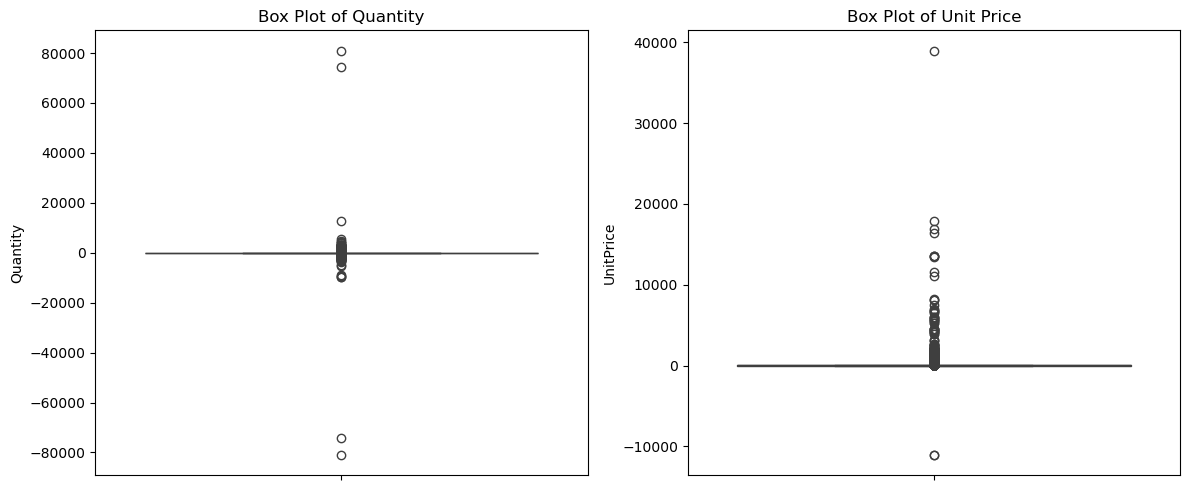

In [8]:
plt.figure(figsize=(12, 5))

# Box plot for Quantity
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Box Plot of Quantity')

# Box plot for UnitPrice
plt.subplot(1, 2, 2)
sns.boxplot(y=df['UnitPrice'])
plt.title('Box Plot of Unit Price')

plt.tight_layout() # Adjusts spacing automatically
plt.show()

In [9]:
# Statistical description of Categorical Variables
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


### **Inferences:**

*  **Number of Entries:** The dataset consists of **541909 entries**, ranging from index 0 to 541908.

*  **Columns:** There are total **8 columns** in the dataset.

*  **Data Types:** **5 columns** are of the **object** data type, **2 coulumns** are of **float64** data type and only a **single column** is of **int64** datatype.
*   **Quantity:** From the statistical description, we can see that the **average product quantity** is approximately **9.55**, while the **minimum quantity** is **-80,995** and the **maximum quantity** is **80,995**. This indicates the presence of **Outliers**. The **negative quantity values** may represent **returned or cancelled orders** rather than actual product quantities delivered.

*  **UnitPrice:** We can see that the **average unit price** is approximately **4.61**, while the **minimum unit price** is **-11062.06** and the **maximum unit price** is **38,970**. This indicates the presence of **Outliers**. The **negative quantity values** may represent **returned or cancelled orders** rather than actual product quantities delivered. The negative unit price may indicate **refunds**, **credit notes**, **pricing** **adjustments**, or **data entry errors**, as product prices are generally not expected to be negative.

*   **Description:** We can see that **WHITE HANGING HEART T-LIGHT HOLDER** is the most frequently purchased product by **Quantity**, with a frequency of **2,369**.
*   **Country:** The **United Kingdom** is the country from which the **highest** number of orders were placed, with a total of **495,478** orders.


## **Step 3:** Data Cleaning

In [10]:
# Creating a copy of the dataset
df_clean = df.copy()

In [11]:
# Convert InvoiceDate to a datetime object so we can calculate days passed
def parse_dates(series):
    # This dataset mixes two date formats in the same column, so we parse them separately.
    s = series.astype(str)
    has_slash = s.str.contains('/')
    out = pd.Series(pd.NaT, index=s.index, dtype='datetime64[ns]')

    # Format 1: 12/31/2011 14:30  (slash, colon)
    out.loc[has_slash] = pd.to_datetime(s[has_slash], format='%m/%d/%Y %H:%M', errors='coerce')

    # Format 2: 12-31-2011 14.30  (dash, dot instead of colon)
    dash_rows = ~has_slash
    fixed = s[dash_rows].str.replace(r'(\d+)\.(\d+)$', r'\1:\2', regex=True)
    out.loc[dash_rows] = pd.to_datetime(fixed, format='%m-%d-%Y %H:%M', errors='coerce')
    return out

df_clean['InvoiceDate'] = parse_dates(df_clean['InvoiceDate'])
print("Parsed date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())
print("Any dates that failed to parse:", df_clean['InvoiceDate'].isna().sum())

Parsed date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Any dates that failed to parse: 0


In [12]:
# Checking missing values
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
# Dropping rows where CustomerID is missing (we can't segment unknown customers)
df_clean = df_clean.dropna(subset=['CustomerID'])
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
# Removing cancelled orders (InvoiceNo starting with "C"), they represent returns,not purchases and would distort spending/frequency figures.
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

In [15]:
# Removing returned or cancelled orders
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

In [16]:
# Checking exact duplicate rows
duplicate_rows = df_clean.duplicated().sum()
print("Exact duplicate rows :", duplicate_rows)

Exact duplicate rows : 5192


In [17]:
# Dropping the duplicate rows
df_clean = df_clean.drop_duplicates()
duplicate_rows2 = df_clean.duplicated().sum()
print("Checking if there is anymore duplicate rows :", duplicate_rows2)

Checking if there is anymore duplicate rows : 0


In [18]:
# Creating a new column which has the Total Price
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)  # Converting the dtype tp int
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [19]:
print("Rows before cleaning:", len(df))
print(f"Rows after cleaning : {len(df_clean):,}  ( {len(df) - len(df_clean):,} rows removed)")
print(f"Unique customers left: {df_clean['CustomerID'].nunique():,}")

Rows before cleaning: 541909
Rows after cleaning : 392,692  ( 149,217 rows removed)
Unique customers left: 4,338


In [20]:
print("Statistical Description After Cleaning the Data:")
df_clean.describe().round(2).T

Statistical Description After Cleaning the Data:


,count,mean,min,25%,50%,75%,max,std
Quantity,392692.0,13.12,1.0,2.0,6.0,12.0,80995.0,180.49
InvoiceDate,392692,2011-07-10 19:13:07.771892480,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392692.0,3.13,0.0,1.25,1.95,3.75,8142.75,22.24
CustomerID,392692.0,15287.84,12346.0,13955.0,15150.0,16791.0,18287.0,1713.54
TotalPrice,392692.0,22.63,0.0,4.95,12.45,19.8,168469.6,311.1


### **Inferences:**
1. **Parse `InvoiceDate` properly.** This file actually mixes two date formats
   (`MM/DD/YYYY HH:MM` and `MM-DD-YYYY HH.MM`) — we handled both with a small helper function.
2. **Dropped rows with missing `CustomerID`.** We can't assign a segment to an unknown customer,
   and these rows can't be fixed.
3. **Removed cancelled orders** (`InvoiceNo` starting with "C") — they represent returns, not
   purchases, and would distort spending/frequency figures.
5. **Removed non-positive `Quantity`/`UnitPrice`** — these are returns or bad records that slipped
   through the invoice-number check, or free/zero-value items that don't reflect real spend.
7. **Dropped duplicate rows.**
8. **Created `TotalPrice` = Quantity x UnitPrice** — the actual amount spent on that line.
9. **Changes** after cleaning the data — The average `Quantity` is increasing to **13.12** from **9.55** and 
   the average of `UnitPrice` is decreasing to **3.13** from **4.61** also
   the maximum `UnitPrice` is decreasing to **8142** from **38,970**, still presence of **Outliers**.

## **Step 4:** Exploratory Data Analysis (EDA)

Now that the data is clean, let's understand **what's actually happening** in the business
before we start segmenting customers.


### **4.1** — Where do customers come from?

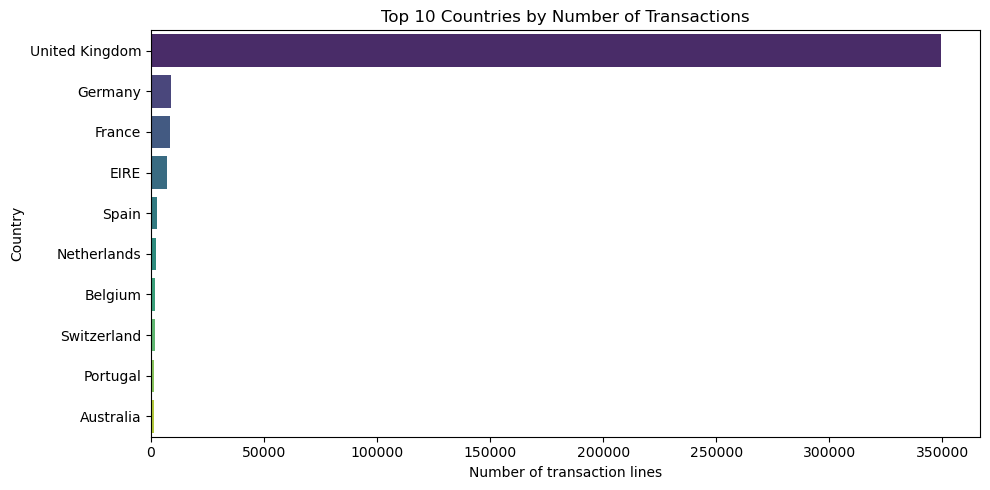

The UK alone accounts for 88.9% of transactions.


In [21]:
# Defining top 10 Countries
top_countries = df_clean['Country'].value_counts().head(10)

# Plotting a barchart 
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of transaction lines')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(f"The UK alone accounts for {df_clean['Country'].value_counts(normalize=True).iloc[0]*100:.1f}% of transactions.")

### **4.2** — How does revenue trend over time?

In [22]:
# Plotting a Trend Line Chart using Plotly
fig = px.line(x=df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum().index,
              y=df_clean.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum().values,
              title='Monthly Revenue Trend', markers=True).update_layout(
    width=1000, height=500, xaxis_title='Month', yaxis_title='Revenue', template='plotly_white')
fig.show()

### **4.3** — Best-selling products by revenue

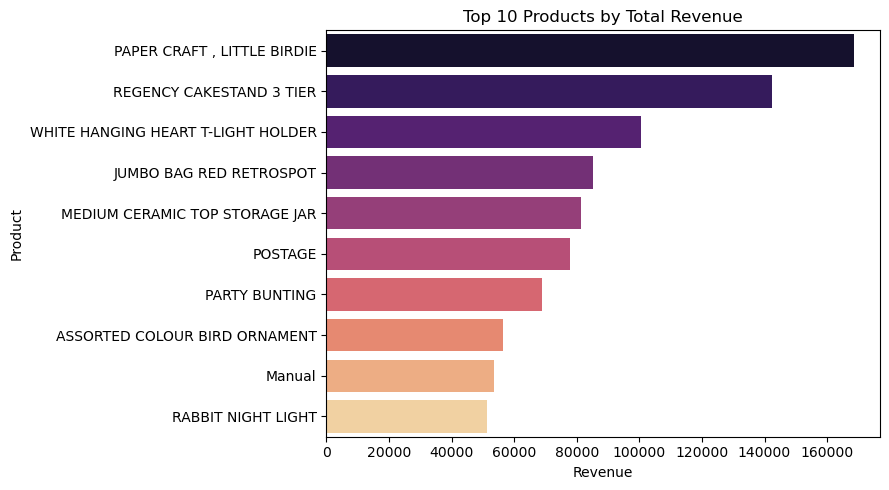

In [23]:
# Defining top 10 products
top_products = (df_clean.groupby('Description')['TotalPrice']
                .sum().sort_values(ascending=False).head(10))

# Plotting a barchart 
plt.figure(figsize=(9,5))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index,
            palette='magma', legend=False)
plt.title('Top 10 Products by Total Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

### **4.4** — Distribution of order line value

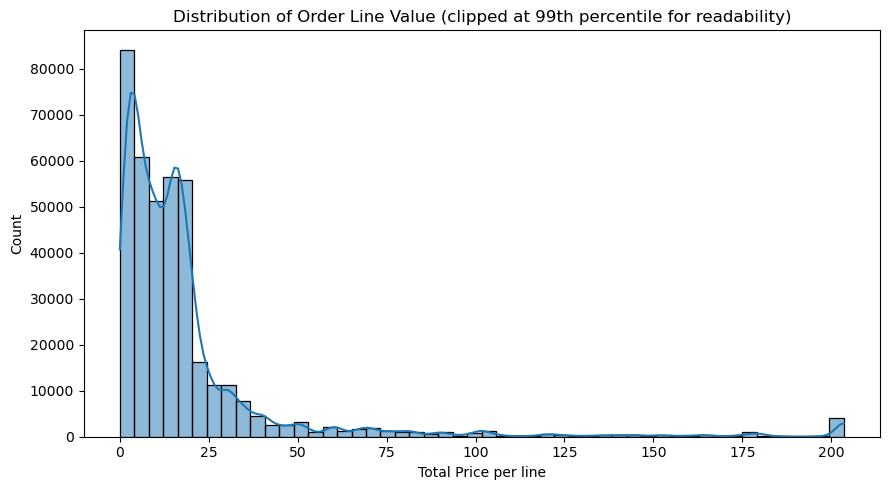

In [24]:
# Plotting a Histogram
plt.figure(figsize=(9,5))

# 'clip' Cuts off any price ABOVE that 99th percentile value
# 'quantile(0.99)' Finds the value where 99% of orders are below the 99th percentile
# Why? To remove extreme outliers so the chart focuses on 99% of normal orders
sns.histplot(df_clean['TotalPrice'].clip(upper=df_clean['TotalPrice'].quantile(0.99)),   
             bins=50, kde=True)                                                        
plt.title('Distribution of Order Line Value (clipped at 99th percentile for readability)')
plt.xlabel('Total Price per line')
plt.tight_layout()
plt.show()

This is heavily right-skewed (a few very large orders), which is completely normal for retail data — it's exactly why we'll need to handle outliers before clustering.

## **Step 5:** Feature Engineering: Building the RFM table

To segment customers we need one row *per customer* (not per transaction line). The industry
standard for this is **RFM**:
It's a way to understand customer behavior by answering 3 questions:

- **Recency**   -> How recently did the customer buy? (lower = more recently active = better)
- **Frequency** -> How often do the customer buy? (higher = more loyal)
- **Monetary**  -> How much money do the customer spend? (higher = more valuable)

We anchor "today" at one day after the last transaction in the dataset (the "snapshot date"),
since we don't have a real "today" for historical data.

In [25]:
# Finding the most recent date in the entire dataset (the last purchase ever made) then adding 1 day to that date
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date used for Recency calculation:", snapshot_date)

# Creating RFM Table
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days), # Subtracting recent purchase date to get no. of days since the last purchase
    Frequency=('InvoiceNo', 'nunique'),  # Counts how many different orders customer made
    Monetary=('TotalPrice', 'sum')   # Calculating their total spending across all orders
).reset_index()  #After grouping by CustomerID, it becomes the index. reset_index() makes CustomerID a normal column again

print("RFM table shape:", rfm.shape)
rfm.describe()

Snapshot date used for Recency calculation: 2011-12-10 12:50:00
RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


### **Inferences:**
* Recency (How recently?) – Average = 93 days. Best = 1 day ago. Worst = 374 days ago.
* Frequency (How often?) – Average = 4 orders. Most common = 1–2 orders. Top = 209 orders.
* Monetary (How much?) – Average = 2,049. Median = 669. Top = 280,206.

We have a large base of occasional, lower-spending customers, and a small group of very loyal, high-spending customers. This gives us a clear opportunity to focus on turning more one-time buyers into repeat customers.

## **Step 6:** Outlier detection & capping (IQR method)

Retail data always has a handful of extreme customers (e.g. wholesalers buying in bulk) that
can distort distance-based algorithms like K-Means. Rather than deleting these customers
(we don't want to lose real business insight), we **cap** them to the IQR bounds:

Lower bound = Q1 - 1.5 x IQR, Upper bound = Q3 + 1.5 x IQR

Any value beyond these bounds is pulled in ("capped") to the bound itself, instead of being
deleted.

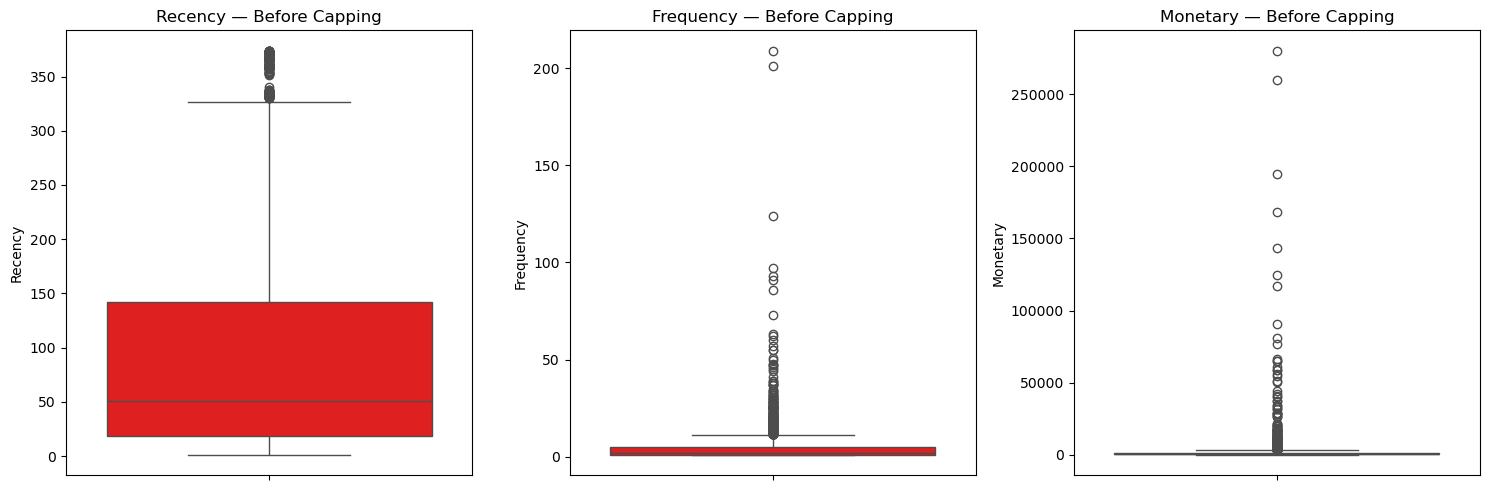

In [26]:
# Plotting a Boxplot for RFM before Outliers Capping
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['Recency','Frequency','Monetary']):
    sns.boxplot(y=rfm[col], ax=ax, color='red')
    ax.set_title(f'{col} — Before Capping')
plt.tight_layout()
plt.show()

In [27]:
# Capping the Outliers using IQR bounds
def iqr_cap(series):     # Capping Function
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series.clip(lower, upper), lower, upper

# Creating a copy of the RFM
rfm_capped = rfm.copy()   

for col in ['Recency', 'Frequency', 'Monetary']:
    capped_series, lo, hi = iqr_cap(rfm[col])
    n_affected = ((rfm[col] < lo) | (rfm[col] > hi)).sum()
    rfm_capped[col] = capped_series
    print(f"{col:10s} bounds: [{lo:.2f}, {hi:.2f}]  ->  {n_affected} customers capped")

Recency    bounds: [-168.00, 328.00]  ->  155 customers capped
Frequency  bounds: [-5.00, 11.00]  ->  285 customers capped
Monetary   bounds: [-1724.69, 3691.77]  ->  425 customers capped


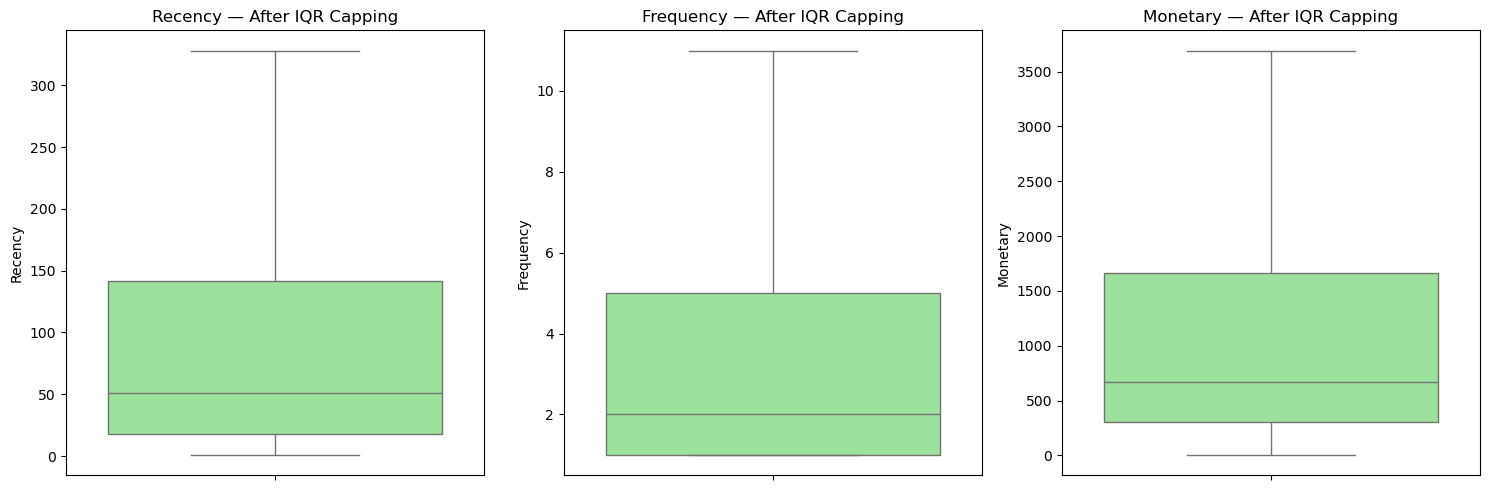

In [28]:
# Plotting a box plot after Outliers are Capped
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, col in zip(axes, ['Recency','Frequency','Monetary']):
    sns.boxplot(y=rfm_capped[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col} — After IQR Capping')
plt.tight_layout()
plt.show()

In [29]:
rfm_capped.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.2500,15299.50,16778.7500,18287.00
Recency,4338.0,91.447441,97.199547,1.00,18.0000,51.00,142.0000,328.00
Frequency,4338.0,3.486630,3.040110,1.00,1.0000,2.00,5.0000,11.00
Monetary,4338.0,1159.010762,1146.777473,3.75,306.4825,668.57,1660.5975,3691.77


## **Step 7:** Feature scaling




In [30]:
features = ['Recency', 'Frequency', 'Monetary']
X = rfm_capped[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe().round().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,0.0,1.0,-1.0,-1.0,-0.0,1.0,2.0
Frequency,4338.0,0.0,1.0,-1.0,-1.0,-0.0,0.0,2.0
Monetary,4338.0,-0.0,1.0,-1.0,-1.0,-0.0,0.0,2.0


Recency is measured in days, Frequency in order counts, Monetary in currency — completely
different scales. Clustering algorithms measure *distance*, so without scaling, Monetary
(with the biggest numbers) would dominate the result. I used `StandardScaler` to put all
three features on the same footing (mean 0, standard deviation 1).

## **Step 8:** Clustering: Finding Customer Segments

We'll try **three different clustering algorithms** and compare them fairly using the
**Silhouette Score** — a metric between -1 and 1 that measures how well-separated the
clusters are (higher = better; points are close to their own cluster and far from others).


### **8.1** — K-Means

K-Means needs us to choose `k` (the number of clusters) upfront. We test a range of `k`
values and look at:
- The **Elbow plot** (inertia — lower is tighter clusters, but always decreases with more k)
- The **Silhouette Score** (this is what actually tells us the best k)


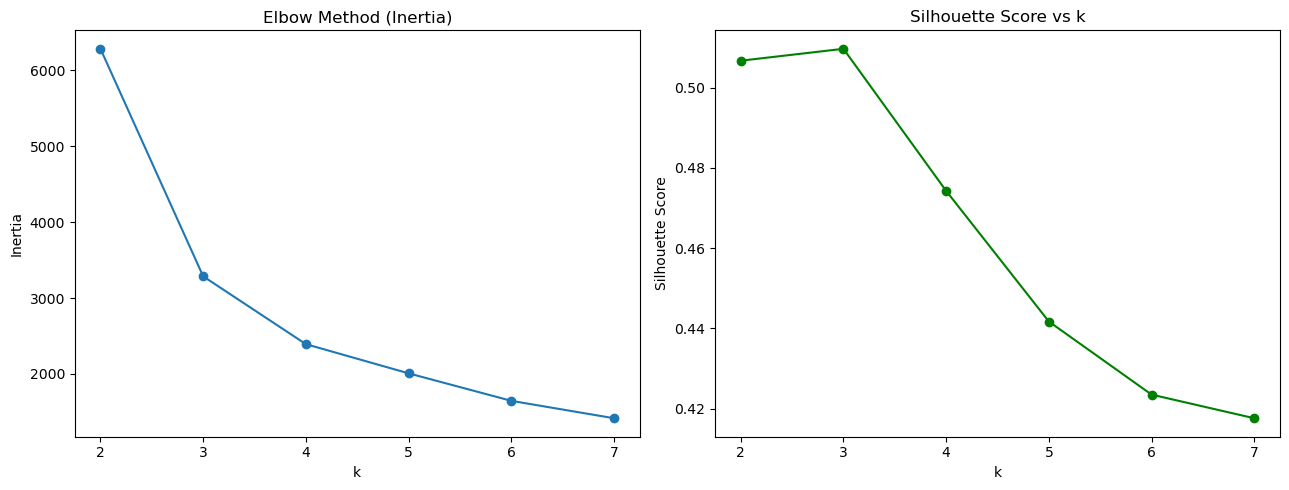

Best k by silhouette score: 3


In [31]:
k_range = range(2, 8)   # Defining the range of Cluster Values
inertias = []           # Empty list to store the inertia (WCSS) for each value of k
sil_scores_kmeans = []  # Empty list to store the silhouette score for each value of k.

# finding the ideal value of k for clustering
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)   # n_init=10 runs the algorithm 10 times to find the best clustering
    labels = km.fit_predict(X_scaled) 
    inertias.append(km.inertia_)
    sil_scores_kmeans.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Plotting Elbow Method graph to identify the optimal no. of clusters by comparing inertia for different values of k.
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

# Plotting Silhouette Score graph to find the value of k that produces the best-quality clusters (higher score is better)
axes[1].plot(list(k_range), sil_scores_kmeans, marker='o', color='green')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores_kmeans))]
print(f"Best k by silhouette score: {best_k}")

We'll pick **k = 3**. It gives (close to) the top silhouette score *and* produces a
number of segments that's actually usable for a marketing team — 3 clean, interpretable
groups instead of many overlapping small ones.

In [32]:
# Building the final K-Means model using the optimal value of k (3) and evaluating its clustering quality using the Silhouette Score
kmeans_final = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)  # Runs the algorithm on the data and assigns each customer to the nearest cluster
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means (k=3) Silhouette Score: {kmeans_sil:.4f}")

K-Means (k=3) Silhouette Score: 0.5097


### **8.2** — Hierarchical (Agglomerative) Clustering

This algorithm builds a tree of clusters by repeatedly merging the closest pairs of
points/clusters. The **dendrogram** visualizes those merges — the height of each
join shows how "far apart" the merged groups were.

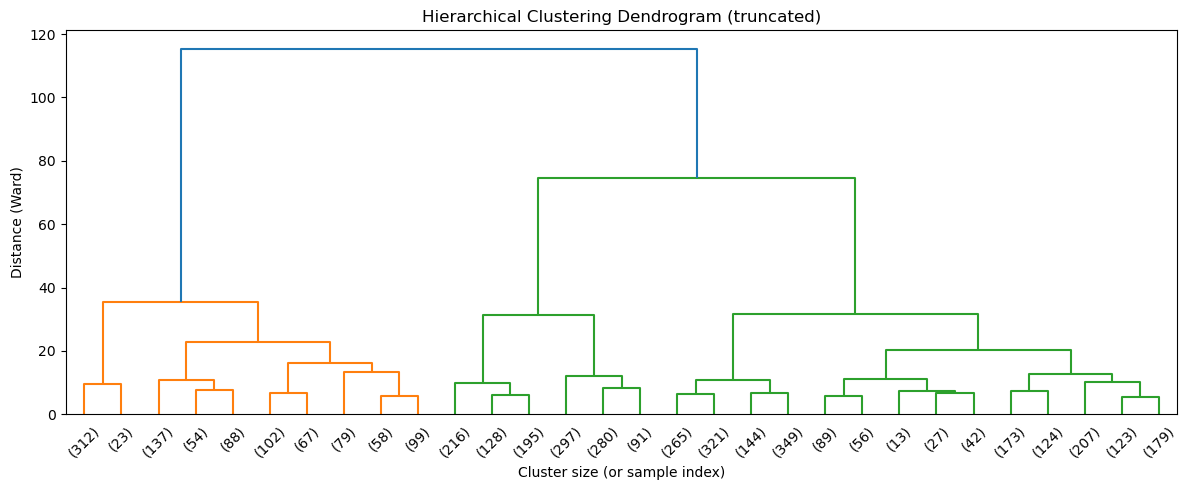

In [33]:
# Performing clustering on the scaled data using the Ward method, which merges clusters while minimizing the increase in variance
linked = linkage(X_scaled, method='ward') 

plt.figure(figsize=(12,5))

# A full dendrogram is unreadable so Dendrogram is truncated to the last 30 merges for readability — with 4000+ customers
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Cluster size (or sample index)')
plt.ylabel('Distance (Ward)')
plt.tight_layout()
plt.show()

In [34]:
# Building the final Hierarchical Clustering model with 3 clusters and evaluating its clustering quality using the Silhouette Score
hier_final = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hier_final.fit_predict(X_scaled)
hier_sil = silhouette_score(X_scaled, hier_labels)
print(f"Hierarchical (k=3) Silhouette Score: {hier_sil:.4f}")

Hierarchical (k=3) Silhouette Score: 0.4651


### **8.3** — DBSCAN

Unlike K-Means and Hierarchical, DBSCAN doesn't need `k` — instead it needs `eps` (how close
points must be to be considered neighbours) and `min_samples`. We use a **k-distance plot**
to pick a sensible `eps`: we look for the "elbow" where distances start increasing sharply.


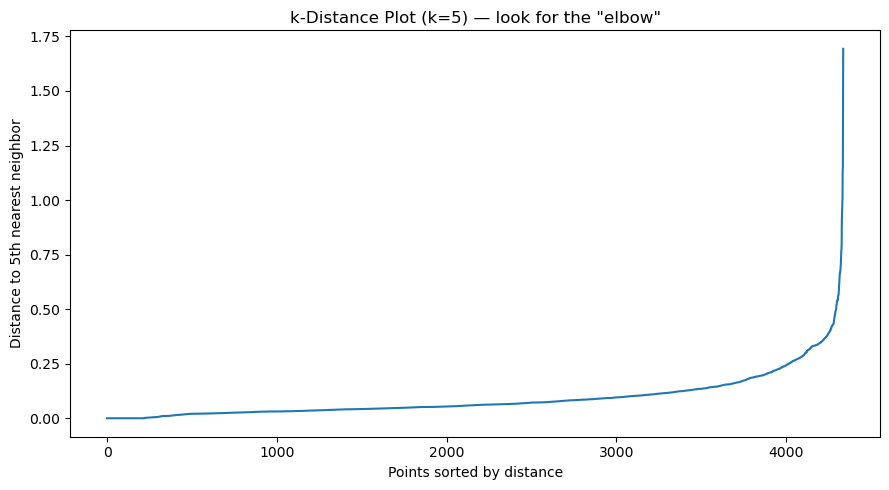

In [35]:
# Determinining the optimal eps value for DBSCAN
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Plotting the k-distance graph to find the elbow point and determine the optimal eps value for DBSCAN
plt.figure(figsize=(9,5))
plt.plot(k_distances)
plt.title(f'k-Distance Plot (k={min_samples}) — look for the "elbow"')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.tight_layout()
plt.show()

In [36]:
# Building the final DBSCAN model
dbscan_final = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

# Identifying clusters and noise points
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0) # Counts the number of clusters found, excluding the noise cluster (-1)
n_noise = (dbscan_labels == -1).sum()  # Counts how many data points were identified as noise (outliers)
print(f"DBSCAN found {n_clusters_db} clusters and flagged {n_noise} points as noise/outliers.")

# Silhouette score can only be computed on the non-noise points
# Evaluating the clustering quality using the Silhouette Score (excluding noise points)
mask = dbscan_labels != -1  # Creating a mask that keeps only the data points that belong to clusters and excludes noise points (-1)
dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
print(f"DBSCAN Silhouette Score (noise points excluded): {dbscan_sil:.4f}")

DBSCAN found 2 clusters and flagged 25 points as noise/outliers.
DBSCAN Silhouette Score (noise points excluded): 0.2393


### **8.4** — Compare all three clustering algorithms

Now the moment of truth — which algorithm actually produced the best-separated segments?


      Algorithm  Silhouette Score  Number of Clusters
0       K-Means          0.509694                   3
1  Hierarchical          0.465103                   3
2        DBSCAN          0.239311                   2


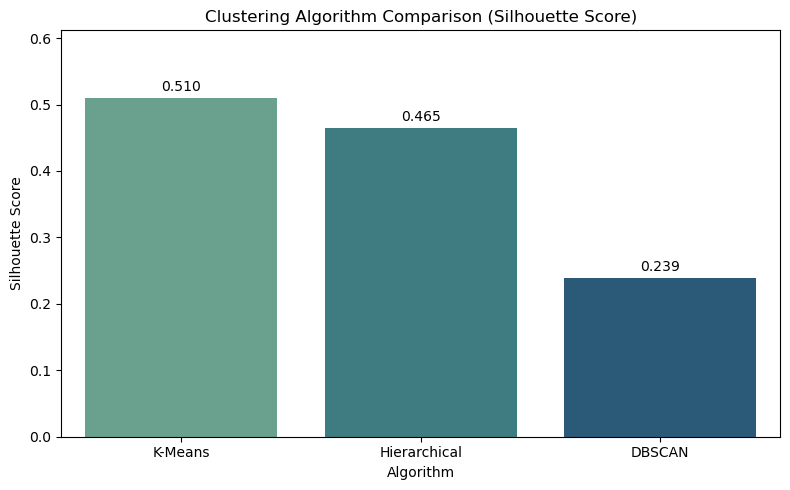


Best algorithm on this dataset: K-Means


In [37]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [kmeans_sil, hier_sil, dbscan_sil],
    'Number of Clusters': [3, 3, n_clusters_db]
}).sort_values('Silhouette Score', ascending=False).reset_index(drop=True)

print(comparison)

plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x='Algorithm', y='Silhouette Score', hue='Algorithm',
            palette='crest', legend=False)
plt.ylim(0, max(comparison['Silhouette Score'])*1.2)
for i, v in enumerate(comparison['Silhouette Score']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.title('Clustering Algorithm Comparison (Silhouette Score)')
plt.tight_layout()
plt.show()

best_algo = comparison.iloc[0]['Algorithm']
print(f"\nBest algorithm on this dataset: {best_algo}")

**Why K-Means/Hierarchical beat DBSCAN here:** DBSCAN is built to find clusters of
*varying density and arbitrary shape*, and to flag outliers as noise. RFM customer data,
after IQR-capping and scaling, tends to form fairly convex, similar-density blobs (e.g. a
"big spenders" group, a "one-time buyers" group) — exactly the situation K-Means and Ward
hierarchical clustering handle best. That's the finding here, and it's a legitimate result,
not a failure of the analysis.

We'll move forward with **K-Means (k=3)** as our final segmentation, since it scored highest
and is also the easiest to explain and reproduce for a business audience.


In [38]:
rfm_capped['Cluster'] = kmeans_labels # Adding cluster numbers to the customer data
final_labels = kmeans_labels

## **Step 9:** Visualizing the Clusters (PCA)

We have 3 features (Recency, Frequency, Monetary) — too many to plot directly in 2D. We use
**PCA (Principal Component Analysis)** to compress them into 2 dimensions that capture as
much of the original variation as possible, purely so we can *see* the clusters.


Variance explained by 2 components: 94.2%
[[-0.4663588   0.63119318  0.61976176]
 [ 0.8828196   0.2877226   0.37127517]]
How valuable is the customer? (PC1)
How recent is their activity? (PC2)


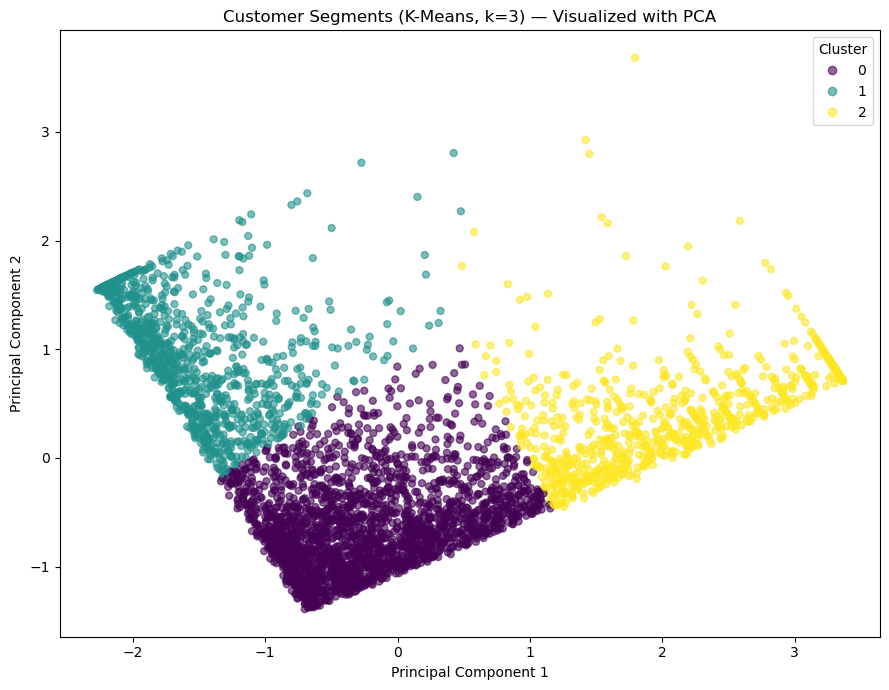

In [39]:
# Doing Principle Component Analysis in order to reduce data from 3 to 2 dimensions so we can visualize it
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")  # How much information has been kept
print(pca.components_)
print("How valuable is the customer? (PC1)")
print("How recent is their activity? (PC2)")

# Plotting a Scatter Plot
plt.figure(figsize=(9,7))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=final_labels, cmap='viridis', alpha=0.6, s=25)
plt.title('Customer Segments (K-Means, k=3) — Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()

In the first row of pca_components we can see that the first column (Recency) is negative which means that Recency in PCA 1 is having a negative influence. Therefore, we are taking Frequency and Monetary in PCA 1 as they have a strong influence, and in PCA 2 we can see that Recency has strong influence so wee are taking it in PCA 2.

## **Step 10:** Profiling the clusters & giving them business names

Cluster numbers (0, 1, 2) mean nothing to a marketing team. Let's look at the actual
Recency/Frequency/Monetary averages per cluster and translate them into names a business
can act on.


In [40]:
profile = rfm_capped.groupby('Cluster')[features].mean().round(1)
profile['Customer Count'] = rfm_capped['Cluster'].value_counts()
print(profile)

         Recency  Frequency  Monetary  Customer Count
Cluster                                              
0           49.1        2.5     726.1            2328
1          245.2        1.5     426.6            1046
2           26.9        8.2    2999.1             964


* Cluster 0 = Occasional SHoppers (bought a few times but need motivation)
* Cluster 1 = At-Risk / Churned Customers (bought once and disappeared - need to win them back!) 
* Cluster 2 = Best Customers (big spenders, loyal, recent)

In [41]:
# Automatically rank clusters into business-friendly names based on their RFM profile.
# Lower Recency = more recent buyer (better). Higher Frequency & Monetary = better.
score = (-profile['Recency']).rank() + profile['Frequency'].rank() + profile['Monetary'].rank()
ranked = score.sort_values(ascending=False)

segment_names = {}
labels_ordered = ['Best Customers', ' Occasional Shoppers', 'At-Risk/Churned Customers']
for cluster_id, name in zip(ranked.index, labels_ordered):    # Looping through each cluster and assigning the name
    segment_names[cluster_id] = name

rfm_capped['Segment'] = rfm_capped['Cluster'].map(segment_names)      # Adding a new column to RFM dataframe with readable segment names
profile['Segment'] = profile.index.map(segment_names)                 # Adding segment names to profile summary table
profile_table = profile[['Segment'] + features + ['Customer Count']]  # Complete profile summary table with segment names
profile_table

,Segment,Recency,Frequency,Monetary,Customer Count
Cluster,,,,,
0,Occasional Shoppers,49.1,2.5,726.1,2328
1,At-Risk/Churned Customers,245.2,1.5,426.6,1046
2,Best Customers,26.9,8.2,2999.1,964


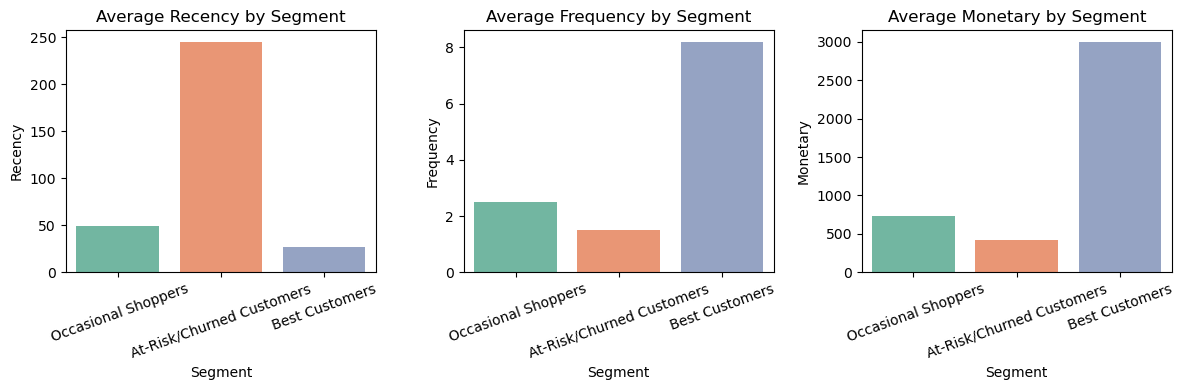

In [42]:
# Create 3 side-by-side bar charts showing average RFM metrics per customer segment
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, col in zip(axes, features):
    sns.barplot(x=profile['Segment'], y=profile[col], hue=profile['Segment'],
                palette='Set2', ax=ax, legend=False)
    ax.set_title(f'Average {col} by Segment')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### **Interpretation:**
Segment -- Strategy -- Action
* Occasional Shoppers -- Encourage them to buy more often (more orders) -- Promotions, Bundle Deals
* At-Risk/Churned Customers -- URGENT!  Win them back before they're gone forever -- Special Discounts, Feedback Surveys
* Best Customers -- Treat them like royalty, they're our best customers! -- Exclusive Perks, Loyalty Rewards

## **Step 11:** Predictive Modeling

Clustering gave us the segments, but it's an **unsupervised** technique — it can't classify a
*brand-new* customer on the fly without re-running the whole clustering pipeline.

So now we do something very common in real-world data science: we treat the cluster labels
as the "ground truth" and train **supervised classification models** to predict which
segment a customer belongs to, based on their RFM values. This gives us:

1. A fast, reusable way to classify new/incoming customers into existing segments
2. A way to double-check that the segments are actually learnable/consistent (if models
   can't predict them well, the segments may not be meaningfully separated)
3. Feature importance via SHAP — which RFM metric matters most for each segment

### **11.1** — Train / Test Split

In [43]:
# Splitting 80% of data into Training set and 20% of data into Test set from rfm_capped
X_model = rfm_capped[features]   # Features = Selects only the RFM columns (Recency, Frequency, Monetary)
y_model = rfm_capped['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model
)
print(f"Training set: {X_train.shape[0]} customers | Test set: {X_test.shape[0]} customers")

Training set: 3470 customers | Test set: 868 customers


### **11.2** — Model 1 : Logistic Regression

A simple, fast linear baseline model

In [44]:
# Model fitting
log_reg = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE,
    C=0.1,              # Lower = stronger regularization (default=1.0)
    penalty='l2',       # L2 = Ridge Regression
    solver='lbfgs'      # Optimization algorithm for L2 + large datasets
)
log_reg.fit(X_train, y_train)

# Making predictions
log_reg_preds_train = log_reg.predict(X_train)  # Predictions on training data
log_reg_preds_test = log_reg.predict(X_test)    # Predictions on test data

# Calculating accuracies
log_reg_acc_train = accuracy_score(y_train, log_reg_preds_train)
log_reg_acc_test = accuracy_score(y_test, log_reg_preds_test)

print(f"Train Accuracy: {log_reg_acc_train:.4f}")
print(f"Logistic Regression Accuracy: {log_reg_acc_test:.4f}\n")
print(classification_report(y_test, log_reg_preds_test))

Train Accuracy: 0.9951
Logistic Regression Accuracy: 0.9919

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       466
           1       0.99      0.99      0.99       209
           2       0.99      0.99      0.99       193

    accuracy                           0.99       868
   macro avg       0.99      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



### **11.3** — Model 2 : Random Forest

An ensemble of many decision trees. Handles non-linear relationships well and is generally
robust with little tuning.

In [45]:
# Parameter grid
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10]
}

# Randomized search
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf, 
    param_grid, 
    n_iter=20,           # Try 20 combinations
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Model fitting
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_
print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")

# Train accuracy
rf_preds_train = best_rf.predict(X_train)
rf_acc_train = accuracy_score(y_train, rf_preds_train)
print(f"Train Accuracy: {rf_acc_train:.4f}\n")

# Test accuracy
rf_preds_test = best_rf.predict(X_test)
rf_acc_test = accuracy_score(y_test, rf_preds_test)
print(f"Test Accuracy: {rf_acc_test:.4f}\n")
print(classification_report(y_test, rf_preds_test))

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV Score: 0.9922
Train Accuracy: 0.9986

Test Accuracy: 0.9885

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       466
           1       0.97      1.00      0.98       209
           2       0.98      0.99      0.99       193

    accuracy                           0.99       868
   macro avg       0.98      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



### **11.4** — Model 3 : XGBoost

A gradient-boosted tree ensemble — usually the strongest "out of the box" tabular model.

In [46]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.4, 0.6, 0.8],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

# Randomized search
xgb_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')
random_search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    n_iter=30,          # Try 30 combinations
    cv=5,
    scoring='accuracy',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_
print(f"Best Params: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}\n")

# Predictions
xgb_preds_train = best_xgb.predict(X_train)
xgb_preds_test = best_xgb.predict(X_test)

xgb_acc_train = accuracy_score(y_train, xgb_preds_train)
xgb_acc_test = accuracy_score(y_test, xgb_preds_test)

print(f"Train Accuracy: {xgb_acc_train:.4f}")
print(f"XGBoost Accuracy: {xgb_acc_test:.4f}\n")
print(classification_report(y_test, xgb_preds_test))

Best Params: {'subsample': 0.4, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV Score: 0.9934

Train Accuracy: 0.9997
XGBoost Accuracy: 0.9873

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       466
           1       0.97      0.99      0.98       209
           2       0.98      0.99      0.98       193

    accuracy                           0.99       868
   macro avg       0.98      0.99      0.99       868
weighted avg       0.99      0.99      0.99       868



## **Step 12:** Comparing Model Accuracy

                 Model  Accuracy
0  Logistic Regression  0.991935
1        Random Forest  0.988479
2              XGBoost  0.987327


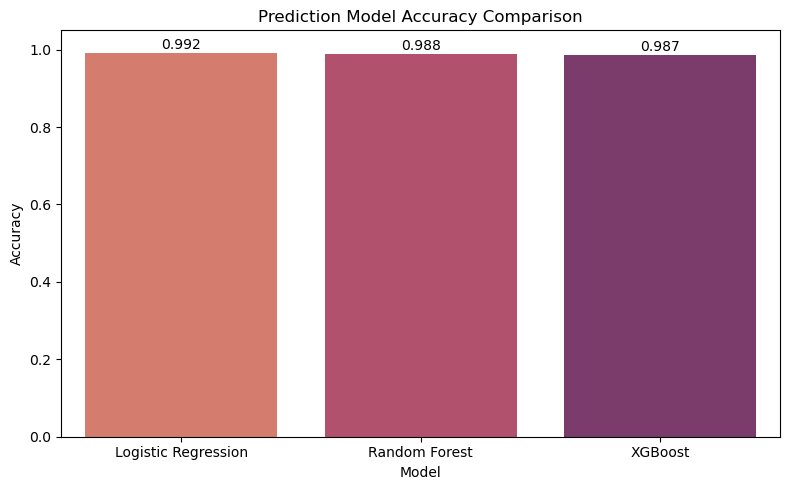


Best predictive model: Logistic Regression


In [47]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [log_reg_acc_test, rf_acc_test, xgb_acc_test]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(model_comparison)

plt.figure(figsize=(8,5))
sns.barplot(data=model_comparison, x='Model', y='Accuracy', hue='Model',
            palette='flare', legend=False)
plt.ylim(0, 1.05)
for i, v in enumerate(model_comparison['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.title('Prediction Model Accuracy Comparison')
plt.tight_layout()
plt.show()

best_model_name = model_comparison.iloc[0]['Model']
print(f"\nBest predictive model: {best_model_name}")

**Why is the accuracy so high for all three models?**
The labels we are predicting were created using the **same three RFM features** with the K-Means clustering algorithm. Since the clusters are well separated (as confirmed by the silhouette score), it is easy for the classification models to learn and predict them correctly. This high accuracy is expected and shows that the customer segments are **clear**, **consistent**, and **well-defined** rather than **random** or **noisy**.

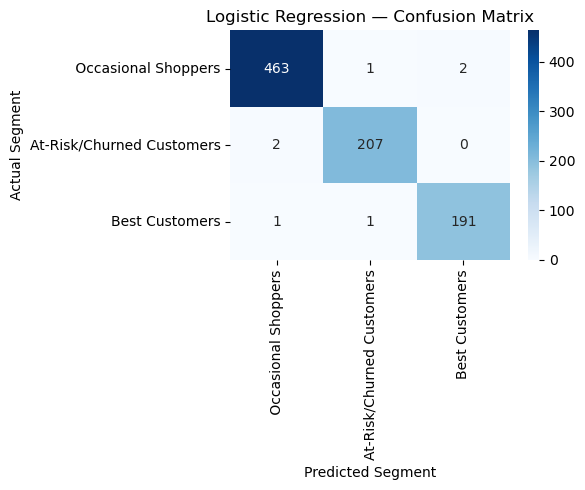

In [48]:
# Plotting a Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, log_reg_preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[segment_names[c] for c in sorted(rfm_capped['Cluster'].unique())],
            yticklabels=[segment_names[c] for c in sorted(rfm_capped['Cluster'].unique())])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual Segment')
plt.xlabel('Predicted Segment')
plt.tight_layout()
plt.show()

## **Step 13:** Feature Importance with SHAP

**SHAP (SHapley Additive exPlanations)** is a tool that helps us look inside our AI model and see exactly why it makes its decisions. For every customer, it shows us how their specific habits— **how recently they shopped, how often do they shop, and how much they spend** —influenced the model's final prediction.

When we look at all of our customers together, SHAP shows us which of those three habits is the most important overall, and how they change the results. 

In [49]:
explainer = shap.KernelExplainer(log_reg.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

# Split into one 2D array per segment, for plotting
class_ids = sorted(rfm_capped['Cluster'].unique())
shap_by_class = [shap_values[:, :, i] for i in range(len(class_ids))]  # Finding the shap values for all the clusters
class_labels_for_plot = [segment_names[c] for c in class_ids]  # Converting a list of raw cluster numbers into human-readable text labels

Using 3470 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/868 [00:00<?, ?it/s]

SHAP values shape: (868, 3, 3)


**Overall feature importance** (averaged across all three segments) — which feature
drives segment assignment the most, in general:

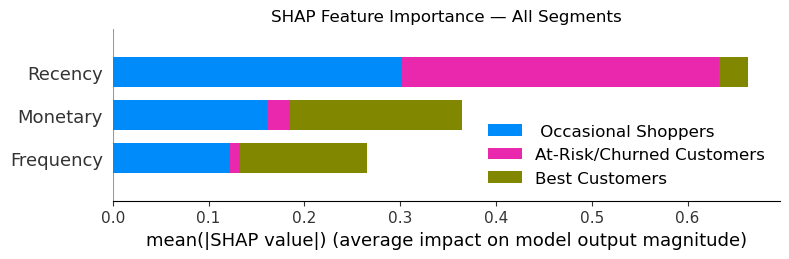

In [ ]:
# Plotting a summary plot
plt.figure()
shap.summary_plot(shap_by_class, X_test, plot_type='bar',
                   class_names=class_labels_for_plot, show=False)
plt.title('SHAP Feature Importance — All Segments')
plt.tight_layout()
plt.show()

**Detailed view for the "Best Customers" segment** — the beeswarm plot below shows, for every
customer, how each feature's value (color = high/low) pushed the prediction toward or away
from being classified as a "Best Customers".

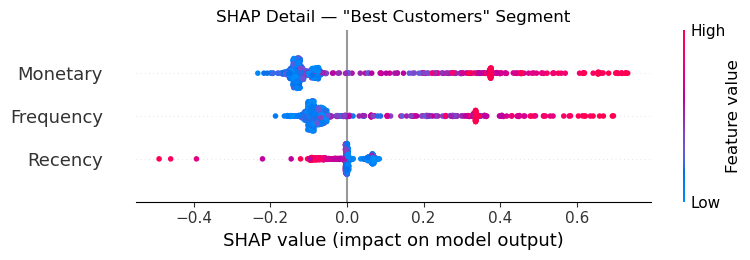

In [ ]:
champions_cluster_id = [cid for cid, name in segment_names.items() if 'Best Customers' in name][0]
champions_idx = class_ids.index(champions_cluster_id)

# Plotting a beeswarm plot
plt.figure()
shap.summary_plot(shap_by_class[champions_idx], X_test, show=False)
plt.title('SHAP Detail — "Best Customers" Segment')
plt.tight_layout()
plt.show()

**How to read this:** each dot is one customer. Red = high value for that feature,
blue = low value. Position on the x-axis shows whether that feature pushed the prediction
*toward* (positive) or *away from* (negative) being classified as a Best Customers. This lets us
say, in plain terms, exactly which behaviours define each segment — not just guess from
averages.

## **Step 14:** Business Insights & Recommendations

Combining the cluster profiles (Step 10) with the SHAP feature importance (Step 17), here
are the segments discovered in this dataset and suggested actions for each.

In [ ]:
print("="*70)
for cluster_id in sorted(rfm_capped['Cluster'].unique()):
    seg = profile.loc[cluster_id]
    print(f"SEGMENT: {seg['Segment']}  (n = {int(seg['Customer Count'])} customers, "
          f"{seg['Customer Count']/len(rfm_capped)*100:.1f}% of customer base)")
    print(f"  Avg Recency   : {seg['Recency']:.0f} days since last purchase")
    print(f"  Avg Frequency : {seg['Frequency']:.1f} orders")
    print(f"  Avg Monetary  : {seg['Monetary']:.2f} total spend")
    print("-"*70)

SEGMENT:  Occasional Shoppers  (n = 2328 customers, 53.7% of customer base)
  Avg Recency   : 49 days since last purchase
  Avg Frequency : 2.5 orders
  Avg Monetary  : 726.10 total spend
----------------------------------------------------------------------
SEGMENT: At-Risk/Churned Customers  (n = 1046 customers, 24.1% of customer base)
  Avg Recency   : 245 days since last purchase
  Avg Frequency : 1.5 orders
  Avg Monetary  : 426.60 total spend
----------------------------------------------------------------------
SEGMENT: Best Customers  (n = 964 customers, 22.2% of customer base)
  Avg Recency   : 27 days since last purchase
  Avg Frequency : 8.2 orders
  Avg Monetary  : 2999.10 total spend
----------------------------------------------------------------------



**Best Customers** — recent, frequent, high-spending.
- Reward with a loyalty/VIP program, early access to new products, and personalized thank-you
  communication. These customers drive disproportionate revenue — protect the relationship,
  don't just upsell.

**Occational Shoppers** — moderate on all three RFM dimensions.
- Nurture with targeted cross-sell campaigns and incentives (e.g. "spend X more to unlock Y")
  to increase order frequency and push them toward Best Customers status.

**At-Risk/Churned Customers** — haven't purchased in a long time, low frequency, low spend.
- Run a win-back campaign (discount codes, "we miss you" emails). For long-dormant, low-value
  customers, consider whether continued marketing spend is worthwhile versus focusing budget
  on the other two segments.

**General Recommendation:** Since **Recency** and **Monetary** matter the most, our marketing should focus on two main goals:

1. Get them to buy sooner: Send reminders and limited-time offers so they don't slip away into the "At-Risk" group.
2. Get them to spend more: Offer product bundles and upsells to turn them into "Best Customers."


## **Step 15:** Conclusion

**Summary of what we did:**
1. Cleaned transaction-level retail data (handled mixed date formats, cancellations, missing
   customer IDs).
2. Engineered an RFM (Recency, Frequency, Monetary) profile per customer.
3. Capped outliers using the IQR method rather than deleting them.
4. Compared three clustering algorithms (K-Means, Hierarchical, DBSCAN) using Silhouette
   Score, and found **K-Means (k=3)** performed best on this data.
5. Turned the 3 clusters into named, actionable business segments.
6. Trained three supervised models (Logistic Regression, Random Forest, XGBoost) to predict
   segment membership from RFM values — all performed strongly, confirming the segments are
   well-separated and consistent.
7. Used **SHAP** to explain exactly which features drive each segment's classification.
8. Translated all of this into concrete marketing/retention recommendations.

**Possible next steps:**
- Bring in additional features (e.g. product category preferences, average discount usage,
  return rate) to enrich the segmentation beyond pure RFM.
- Re-run this pipeline periodically (e.g. monthly) to track how customers migrate between
  segments over time.
- A/B test the recommended retention campaigns per segment and measure actual impact on
  Recency/Frequency/Monetary in the following period.